# Тема 3. Деревья решений и метод ближайших соседей

## Дополнительные материалы (самостоятельное чтение)

На занятии не разбираем. Три темы:

1. Распознавание рукописных цифр — где kNN неожиданно обгоняет дерево
2. Проклятие размерности — почему kNN плохо работает в пространствах с большим числом признаков
3. `GridSearchCV` — автоматический подбор `max_depth` вместо подбора руками; дерево для регрессии

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_digits

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

---
## 1. MNIST: kNN обгоняет дерево

На занятии дерево решений уверенно обошло kNN (94% против 89%) на данных оттока. Проверим то же на другой задаче — распознавании рукописных цифр 8×8 пикселей (`sklearn.datasets.load_digits`, упрощённая версия MNIST).

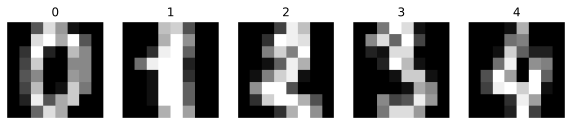

In [2]:
digits = load_digits()
_, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.imshow(image, cmap="gray")
    ax.set_title(label)
    ax.axis("off")

In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=RANDOM_STATE
)

tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(X_train, y_train)
knn = KNeighborsClassifier(n_neighbors=10).fit(X_train, y_train)

print("Дерево:", round(tree.score(X_valid, y_valid), 3))
print("kNN:   ", round(knn.score(X_valid, y_valid), 3))

Дерево: 0.659
kNN:    0.981


Теперь **kNN заметно выигрывает** (~98% против ~66% у дерева той же глубины). Каждый пиксель — отдельный признак (64 признака), а классы (одинаковые цифры) образуют в этом 64-мерном пространстве плотные «облака» похожих изображений — идеальные условия для kNN. У дерева, наоборот, нет естественного способа расщеплять по «похожести целой картинки» — оно смотрит на пиксели по одному.

**Вывод:** нет универсально лучшего алгоритма — результат в теме 3 (дерево лучше) и здесь (kNN лучше) одинаково правильные, просто для разных данных.

---
## 2. Проклятие размерности

kNN опирается на понятие «расстояния между точками» и «ближайших соседей». Проблема в том, что в пространствах с большим числом признаков (высокой размерности) это понятие быстро теряет смысл: почти все точки оказываются друг от друга примерно на одинаковом (и большом) расстоянии, и слово «ближайший» перестаёт что-либо означать.

Смоделируем: чем выше размерность случайных точек в кубе, тем меньше разница между расстоянием до ближайшей и до дальней точки.

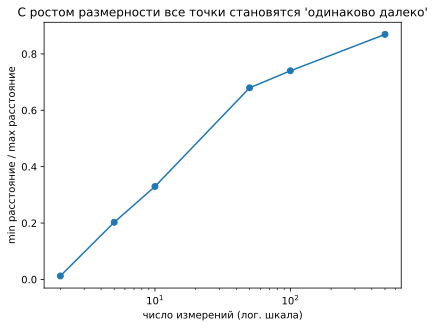

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
ratios = []
dims = [2, 5, 10, 50, 100, 500]
for d in dims:
    points = rng.random((1000, d))
    origin = np.zeros(d)
    dists = np.linalg.norm(points - origin, axis=1)
    ratios.append(dists.min() / dists.max())

plt.plot(dims, ratios, marker="o")
plt.xscale("log")
plt.xlabel("число измерений (лог. шкала)")
plt.ylabel("min расстояние / max расстояние")
plt.title("С ростом размерности все точки становятся 'одинаково далеко'");

Чем больше признаков, тем ближе это отношение к 1 — то есть ближайший и самый дальний сосед почти неотличимы по расстоянию. Практический вывод: перед kNN на данных с большим числом признаков стоит сначала уменьшить размерность (отбор признаков — тема 6, PCA — тема 7) или использовать другой алгоритм.

---
## 3. Автоматический подбор глубины и дерево для регрессии

На занятии мы перебирали `max_depth` вручную и смотрели на график. `GridSearchCV` делает то же самое автоматически, ещё и с кросс-валидацией на каждой комбинации параметров:

In [5]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype(int)
df["International plan"] = (df["International plan"] == "Yes").astype(int)
df["Voice mail plan"] = (df["Voice mail plan"] == "Yes").astype(int)
X = df.drop(columns=["State", "Churn"])
y = df["Churn"]

grid = {"max_depth": [3, 4, 5, 6, 7, 8], "min_samples_leaf": [1, 5, 10, 20]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), grid, cv=5)
gs.fit(X, y)

gs.best_params_, round(gs.best_score_, 4)

({'max_depth': 6, 'min_samples_leaf': 1}, np.float64(0.9427))

`GridSearchCV` нашёл `max_depth=6` — ещё чуть точнее (94.3%), чем `max_depth=5`, который мы взяли на глаз на занятии.

И последнее: деревья решений умеют не только классифицировать, но и предсказывать число (`DecisionTreeRegressor`) — вместо доли класса в листе хранится среднее значение целевой переменной среди попавших в лист наблюдений:

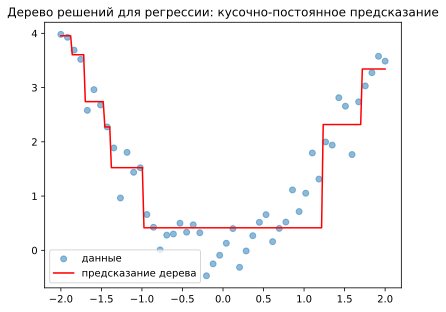

In [6]:
X_toy = np.linspace(-2, 2, 50).reshape(-1, 1)
y_toy = X_toy.ravel() ** 2 + np.random.normal(0, 0.3, 50)

reg = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_toy, y_toy)
X_line = np.linspace(-2, 2, 200).reshape(-1, 1)

plt.scatter(X_toy, y_toy, alpha=0.5, label="данные")
plt.plot(X_line, reg.predict(X_line), color="red", label="предсказание дерева")
plt.legend()
plt.title("Дерево решений для регрессии: кусочно-постоянное предсказание");

Обратите внимание — предсказание дерева **ступенчатое**, а не гладкое: внутри каждого листа предсказание одно и то же (среднее). Это структурное отличие от линейных моделей, к которым переходим на следующем занятии.

---
## Итог

Дальше — `lesson04_linear_models_theory.ipynb`.